In [1]:
q = 2
F = GF(q)

In [9]:
# Sage-proof Green polynomials implementation

from collections import Counter
from math import factorial, comb

# Use Sage integers
from sage.all import Integer, QQ, PolynomialRing

x = PolynomialRing(QQ, 'x').gen()  # Polynomial variable

# -------------------------
# Partition helper
# -------------------------
class Partition:
    def __init__(self, parts):
        parts = tuple(sorted([Integer(p) for p in parts if p > 0], reverse=True))
        self.parts = parts

    def __len__(self):
        return len(self.parts)

    @property
    def sum(self):
        return sum(self.parts)

    def element_at(self, i):
        return self.parts[i]

    def to_row_count_dict(self):
        return dict(Counter(self.parts))

    def delete_first_row(self):
        return Partition(self.parts[1:]) if len(self.parts) > 1 else Partition(())

    def concat(self, other):
        return Partition(self.parts + tuple(other.parts))

    def __repr__(self):
        return f"Partition{self.parts}"

    def __str__(self):
        return str(self.parts)

    def to_key(self):
        return self.parts

    def subpartitions(self):
        counts = self.to_row_count_dict()
        sizes = list(counts.items())
        def rec(i, chosen):
            if i == len(sizes):
                parts = []
                for s, m in chosen:
                    parts.extend([s]*m)
                yield Partition(parts)
            else:
                s, m = sizes[i]
                for take in range(m+1):
                    chosen.append((s,take))
                    yield from rec(i+1, chosen)
                    chosen.pop()
        yield from rec(0, [])

# -------------------------
# Polynomial class (using Sage polynomials)
# -------------------------
class Polynomial:
    def __init__(self, coeffs=None):
        self.R = PolynomialRing(QQ, 'x')
        self.x = self.R.gen()
        if coeffs is None:
            self.poly = self.R(0)
        elif isinstance(coeffs, dict):
            self.poly = sum(QQ(c)*self.x**d for d,c in coeffs.items())
        else:
            self.poly = sum(QQ(c)*self.x**i for i,c in enumerate(coeffs))

    @staticmethod
    def zero():
        return Polynomial({})

    @staticmethod
    def one():
        return Polynomial({0:1})

    def degree(self):
        return self.poly.degree()

    def __add__(self, other):
        p = Polynomial()
        p.poly = self.poly + other.poly
        return p

    def __sub__(self, other):
        p = Polynomial()
        p.poly = self.poly - other.poly
        return p

    def __mul__(self, other):
        p = Polynomial()
        p.poly = self.poly * other.poly
        return p

    def scalar_multiply(self, r):
        p = Polynomial()
        p.poly = self.poly * QQ(r)
        return p

    def involution(self):
        d = self.degree()
        coeffs = {i:self.poly[d-i] for i in range(d+1)}
        return Polynomial(coeffs)

    def __repr__(self):
        return str(self.poly)

# -------------------------
# Partition generation
# -------------------------
def generate_partitions(n):
    if n==0:
        yield Partition([])
        return
    p = Partition([n])
    yield from dominated_partitions(p)

def dominated_partitions(partition):
    current = partition
    while current is not None:
        yield current
        current = next_partition(current)

def next_partition(partition):
    if len(partition)>=1 and partition.element_at(0)==1:
        return None
    i = len(partition)-1
    while i>=0 and partition.element_at(i)==1:
        i -= 1
    if i<0:
        return None
    remove_from_row = i
    new_row_value = partition.element_at(remove_from_row)-1
    new_parts = list(partition.parts[:remove_from_row])
    new_parts.append(new_row_value)
    remaining = partition.sum - sum(new_parts)
    new_parts.extend(complete_partition_maximally(new_row_value, remaining))
    return Partition(new_parts)

def complete_partition_maximally(maxval, length):
    if length==0:
        return []
    q,r = divmod(length, maxval)
    return [maxval]*q + ([r] if r>0 else [])

# -------------------------
# Calculator
# -------------------------
class Calculator:
    def __init__(self):
        self._basic_polys = {}
        self._partition_polys = {}
        self._centralizers = {}
        self._green_polys = {}

    def get_basic_polynomial(self,j):
        if j in self._basic_polys:
            return self._basic_polys[j]
        coeffs = [1] + [0]*(j-1) + [-1]
        p = Polynomial(coeffs)
        self._basic_polys[j] = p
        return p

    def centralizer_size(self, part):
        key = part.to_key()
        if key in self._centralizers:
            return self._centralizers[key]
        res = Integer(1)
        for s,m in part.to_row_count_dict().items():
            res *= s**m * factorial(m)
        self._centralizers[key] = res
        return res

    def z_inverse(self, part):
        key = part.to_key()
        if key in self._partition_polys:
            return self._partition_polys[key]
        res = Polynomial.one()
        for p in part.parts:
            res = res * self.get_basic_polynomial(p)
        res = res.scalar_multiply(1/self.centralizer_size(part))
        self._partition_polys[key] = res
        return res

    def green_polynomial_X(self, lam, mu):
        key = (lam.to_key(), mu.to_key())
        if key in self._green_polys:
            return self._green_polys[key]
        if lam.sum != mu.sum:
            self._green_polys[key] = Polynomial.zero()
            return Polynomial.zero()
        n = lam.sum
        if len(lam)<=1:
            self._green_polys[key] = Polynomial.one()
            return Polynomial.one()
        result = Polynomial.zero()
        mu_count = mu.to_row_count_dict()
        for tau in mu.subpartitions():
            tau_count = tau.to_row_count_dict()
            binom_prod = Integer(1)
            for s in mu_count.keys():
                binom_prod *= comb(mu_count[s], tau_count.get(s,0))
            remaining_sum = n - lam.element_at(0) - tau.sum
            for rho in generate_partitions(remaining_sum):
                term = self.z_inverse(rho) * self.green_polynomial_X(lam.delete_first_row(), tau.concat(rho))
                term = term.scalar_multiply(binom_prod)
                if len(rho)%2==0:
                    result = result + term
                else:
                    result = result - term
        self._green_polys[key] = result
        return result

    def green_polynomial_Q(self, lam, mu):
        return self.green_polynomial_X(lam, mu).involution()

# -------------------------
# Public function
# -------------------------
def green_polynomial(lambda_parts, mu_parts):
    lam = Partition(lambda_parts)
    mu = Partition(mu_parts)
    return Calculator().green_polynomial_Q(lam, mu)

def gp(lambda_parts):
    """
    Evaluate Q_lambda^{(1^n)}(q_value) where n = sum(lambda_parts).
    """
    q_value = q
    lam = Partition(lambda_parts)
    n = lam.sum
    mu = Partition([1]*n)
    poly = Calculator().green_polynomial_Q(lam, mu)
    return poly.poly(q_value)

def smaller_partitions(partition):
    """Generate all unique partitions obtained by subtracting 1 from a part (no repeats)."""
    result = set()
    for i in range(len(partition)):
        if partition[i] > 0:
            new_partition = partition[:]
            new_partition[i] -= 1
            if new_partition[i] == 0:
                new_partition.pop(i)
            result.add(tuple(sorted(new_partition, reverse=True)))
    return [list(p) for p in result]

def which_removed(partition, smaller_partition):
    for i, p in enumerate(partition):
        if i >= len(smaller_partition) or p - smaller_partition[i] == 1:
            return i
    raise ValueError("No single decrement/removal found")

def multiplicity(partition, i):
    part_size = partition[i]
    return partition.count(part_size)

def flag_amount(partition, p):
    dec = which_removed(partition, p)
    mult = multiplicity(partition, dec)
    return (q ** mult - 1) * (q ** (dec + 1 - mult))

def smaller_dict(partition):
    result = {}
    sum = 0
    small = smaller_partitions(partition)
    for p in small:
        weight = flag_amount(partition, p) * gp(p)
        sum += weight
    for p in small:
        result[tuple(p)] = flag_amount(partition, p) * gp(p) / sum
    return result

In [14]:
# Example usage
print(green_polynomial([2,2],[1,1,1,1]))
print(green_polynomial([2,2],[1,1,1,1]))
calc = Calculator()
#print("X:", calc.green_polynomial_X(Partition([2,2]), Partition([1,1,1,1])))
#print("Q:", calc.green_polynomial_Q(Partition([2,2]), Partition([1,1,1,1])))

2*x^2 + 3*x + 1
2*x^2 + 3*x + 1


In [7]:
def random_stabilizer_element(w):
    """
    Uniform random element of stab_U(wB), the stabilizer of wB in U,
    where U is the upper-unitriangular subgroup of GL_n(F_q).

    Input:
      - w : permutation (list/tuple in 1..n or 0..n-1, or Sage Permutation).
      - q : prime power for GF(q).
    Output:
      - n x n matrix over GF(q).
    """
    # normalize w to a list in 1..n
    if hasattr(w, "list"):
        p = list(w.list())
    else:
        p = list(w)
    n = len(p)
    if min(p) == 0:  # 0-based
        p = [x+1 for x in p]

    # compute inverse permutation inv[r-1] = i with p[i-1] = r
    inv = [0]*n
    for i, image in enumerate(p):   # i=0..n-1, image in 1..n
        inv[image-1] = i+1

    F = GF(q)
    M = identity_matrix(F, n)

    for r in range(n):
        for c in range(r+1, n):  # only above diagonal
            if inv[r] <= inv[c]:
                M[r, c] = F.random_element()
            else:
                M[r, c] = F(0)
    return M

def random_nonzero_vector(k):
    # total number of nonzero vectors
    N = q**k - 1
    # pick an integer in [1, N]
    idx = randint(1, N)
    # convert idx into base-q digits
    coords = []
    for _ in range(k):
        coords.append(F(idx % q))
        idx //= q
    v = vector(F, coords)
    return v

In [6]:
def all_stabilizer_elements(w, q):
    """
    List of all elements of stab_U(wB) ⊂ U, 
    the stabilizer of wB in the upper-unitriangular subgroup of GL_n(F_q).

    Input:
      - w : permutation (list/tuple in 1..n or 0..n-1, or Sage Permutation).
      - q : prime power for GF(q).
    Output:
      - list of n x n matrices over GF(q).
    """
    # normalize w to a list in 1..n
    if hasattr(w, "list"):
        p = list(w.list())
    else:
        p = list(w)
    n = len(p)
    if min(p) == 0:  # 0-based
        p = [x+1 for x in p]

    # compute inverse permutation
    inv = [0]*n
    for i, image in enumerate(p):   # i=0..n-1, image in 1..n
        inv[image-1] = i+1

    F = GF(q)

    # collect all free positions
    free_positions = []
    for r in range(n):
        for c in range(r+1, n):   # strictly above diagonal
            if inv[r] <= inv[c]:
                free_positions.append((r, c))

    # generate all matrices
    elements = []
    from itertools import product
    for values in product(F, repeat=len(free_positions)):
        M = identity_matrix(F, n)
        for (val, (r, c)) in zip(values, free_positions):
            M[r, c] = val
        elements.append(M)

    return elements

def conjugates_of_stabilizer(w, u, q):
    """
    Given a permutation w, a matrix u, and a field size q,
    return all elements of the form u * m * u^{-1} 
    where m runs over stab_U(wB).

    Input:
      - w : permutation (list/tuple or Sage Permutation).
      - u : invertible n x n matrix over GF(q).
      - q : prime power for GF(q).

    Output:
      - list of matrices over GF(q).
    """
    U_w = all_stabilizer_elements(w, q)
    u_inv = u.inverse()
    return [u * m * u_inv for m in U_w]

def inter(w, y, u, q):
    """
    Compute | U_w ∩ u U_y u^{-1} |.

    Input:
      - w : permutation (list/tuple or Sage Permutation).
      - y : permutation (list/tuple or Sage Permutation).
      - u : invertible n x n matrix over GF(q).
      - q : prime power for GF(q).

    Output:
      - integer cardinality of the intersection.
    """
    Uw = all_stabilizer_elements(w, q)
    uUy = conjugates_of_stabilizer(y, u, q)

    # Represent each matrix as tuple of row-tuples
    def matrix_to_tuple(M):
        return tuple(tuple(row) for row in M.rows())

    Uw_set  = {matrix_to_tuple(M) for M in Uw}
    uUy_set = {matrix_to_tuple(M) for M in uUy}

    return len(Uw_set & uUy_set)

In [14]:
def quotient_representation(M, v):
    """
    Given a matrix M over GF(q) and a vector v with M*v = v,
    return the induced matrix representation of M on V / <v>,
    together with the basis used for the quotient.
    """
    F = M.base_ring()
    n = M.nrows()
    V = VectorSpace(F, n)
    v = V(v)  # make sure v is a Sage vector
    
    assert M * v == v, "Input vector v must be an eigenvector with eigenvalue 1"
    
    # Extend v to a basis of V
    B = [v]
    for u in V.basis():
        if len(B) == n:
            break
        if u not in span(B):
            B.append(u)
    
    # Change-of-basis matrix
    P = matrix(F, B).transpose()  # columns = basis vectors
    Pinv = P.inverse()
    
    # Conjugate
    Mprime = Pinv * M * P
    
    # Extract bottom-right block
    Mquot = Mprime[1:, 1:]
    
    return Mquot, B

def lift(new_v, basis, original_v):
    """
    Lift a vector from the quotient V/<v> back to V.
    
    INPUT:
      - new_v: vector in F_q^{n-1}, coordinates relative to basis[1:]
      - basis: the basis [v, u2, ..., un] returned from quotient_representation
      - original_v: the vector v spanning <v>
    
    OUTPUT:
      - a representative in V of the coset corresponding to new_v
    """
    F = original_v.base_ring()
    V = VectorSpace(F, len(basis))
    new_v = vector(F, new_v)
    
    # linear combination of basis[1:], ignoring basis[0] = v
    lifted = sum(coeff * b for coeff, b in zip(new_v, basis[1:]))
    return lifted


M = matrix(F, [[1,1,0],[0,1,0],[0,0,2]])
v = vector(F, [1,0,0])

Mquot, B = quotient_representation(M, v)

print(Mquot)

new_v = vector(F, [1,2])  # element of V/<v>
lifted = lift(new_v, B, v)
lifted

[1 0]
[0 0]


(0, 1, 0)

In [15]:
import random

def first_vector_sample(A):
    J, P = A.jordan_form(transformation=True)

    # record the Jordan block sizes
    partition = []
    i = 0
    while i < J.nrows():
        size = 1
        while i+size < J.nrows() and J[i+size-1,i+size] == 1:
            size += 1
        partition.append(size)
        i += size

    sd = smaller_dict(partition)

    # Sample a key from sd with probability proportional to its weight
    keys = list(sd.keys())
    weights = [float(sd[k]) for k in keys]
    sp = random.choices(keys, weights=weights, k=1)[0]

    # Identify which part was decremented 
    dec_size = None 
    for p, s in zip(partition, sp + (0,)*(len(partition)-len(sp))): # pad sp 
        if p != s: 
            dec_size = p 
            break

    n = sum(partition)
    
    # Indices of the first entries of Jordan blocks
    starts = []
    offset = 0
    for block_size in partition:
        starts.append(offset)
        offset += block_size
    
    # Separate indices by block size
    eq_indices = [i for i, bsize in zip(starts, partition) if bsize == dec_size]
    gt_indices = [i for i, bsize in zip(starts, partition) if bsize > dec_size]
    
    v = vector(F, [F(0)]*n)
    
    if eq_indices:
        # sample a nonzero vector over F_q^{len(eq_indices)}
        subv_eq = random_nonzero_vector(len(eq_indices))
        for pos, val in zip(eq_indices, subv_eq):
            v[pos] = val
    
    if gt_indices:
        # sample a fully random vector over F_q^{len(gt_indices)}
        subv_gt = random_vector(F, len(gt_indices))
        for pos, val in zip(gt_indices, subv_gt):
            v[pos] = val

    return P*v

M1 = matrix(F, [[1,1,0],[0,1,0],[0,0,1]])
first_vector_sample(M1)

(1, 0, 0)

In [16]:
def springer_sample_flag(A):
    F = A.base_ring()
    n = A.nrows()
    V = VectorSpace(F, n)
    v = first_vector_sample(A)
    flag = [v]
    if n == 1:
        return flag
    else:
        Aquot, B = quotient_representation(A, v)
        for z in springer_sample_flag(Aquot):
            flag.append(lift(z, B, v))
        return flag

In [17]:
def flag_to_permutation(flag, q=None):
    """
    Given a flag (list of vectors) in F_q^n, return the signature permutation.
    Works naturally with SageMath GF(q) elements (no Fractions).
    """
    if not flag:
        return []
    n = len(flag[0])
    A = [list(row) for row in flag]  # copy

    pivots = []
    for i in range(len(A)):
        # eliminate previously chosen pivot columns from row i
        for r, pc in enumerate(pivots):
            if A[i][pc] != 0:
                factor = A[i][pc] / A[r][pc]  # division is defined in GF(q)
                for c in range(n):
                    A[i][c] -= factor * A[r][c]

        # choose the rightmost nonzero as the new pivot
        pc = None
        for c in range(n-1, -1, -1):
            if A[i][c] != 0:
                pc = c
                break
        if pc is None:
            raise ValueError("Input rows are not a strict flag (dependent row encountered).")
        pivots.append(pc)

    return [c+1 for c in pivots]


# Tests
print(flag_to_permutation([(1,1), (1,0)]))            # [2, 1]
print(flag_to_permutation([(1,0,0),(0,1,0),(0,0,1)])) # [1, 2, 3]


[2, 1]
[1, 2, 3]


In [18]:
def next_step(w):
    u = random_stabilizer_element(w)
    x = springer_sample_flag(u)
    return flag_to_permutation(x)

Saved random_walk.gif


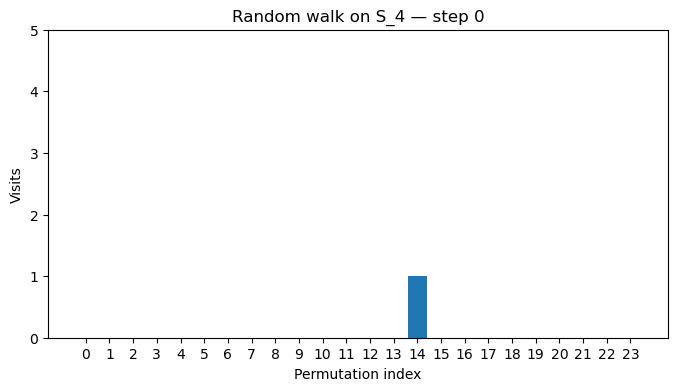

In [19]:
import itertools
import random
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parameters
n = 4  # change to your n
steps = 50

# State space = all permutations (tuples!)
perms = list(itertools.permutations(range(1, n+1)))
perm_to_idx = {p: i for i, p in enumerate(perms)}

# Walk initialization
current = (3, 2, 1, 4) # already a tuple
counts = [0] * len(perms)
history = []

# Run the chain and record visit counts
for t in range(steps):
    counts[perm_to_idx[tuple(current)]] += 1
    history.append(counts[:])  # copy for later animation
    current = next_step(current)

# Animation
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(len(perms)), history[0])
ax.set_xticks(range(len(perms)))
ax.set_ylim(0, max(max(h) for h in history))
ax.set_xlabel("Permutation index")
ax.set_ylabel("Visits")
ax.set_title(f"Random walk on S_{n}")

def update(frame):
    for bar, h in zip(bars, history[frame]):
        bar.set_height(h)
    ax.set_title(f"Random walk on S_{n} — step {frame}")
    return bars

ani = animation.FuncAnimation(fig, update, frames=steps, blit=False, interval=20)

# Save as GIF (requires Pillow)
ani.save("random_walk_3.gif", writer="pillow", fps=30)
print("Saved random_walk.gif")

In [21]:
import itertools
import random
# Parameters
n = 4  # change to your n
steps = 500

# State space = all permutations (tuples!)
perms = list(itertools.permutations(range(1, n+1)))
perm_to_idx = {p: i for i, p in enumerate(perms)}

# Walk initialization
current = (3, 2, 1, 4) # already a tuple
counts = [0] * len(perms)
history = []

# Run the chain and record visit counts
for t in range(steps):
    counts[perm_to_idx[tuple(current)]] += 1
    history.append(counts[:])  # copy for later animation
    current = next_step(current)

print(counts)

[20, 17, 12, 18, 19, 19, 20, 14, 32, 28, 18, 17, 15, 25, 20, 30, 38, 25, 22, 24, 23, 12, 8, 24]


In [22]:
def rs_tableau(perm):
    """
    Given a permutation (as a list), return its insertion tableau
    using the Robinson-Schensted correspondence.
    """
    from sage.combinat.permutation import Permutation
    perm = list(perm)
    pi = Permutation(perm)
    P, Q = pi.robinson_schensted()  # returns a pair of tableaux
    return P

print(rs_tableau((1,2,3)))

[[1, 2, 3]]


In [17]:
Permutation([1,2,3]).robinson_schensted()

[[[1, 2, 3]], [[1, 2, 3]]]